# Predicting Solar Energy Production
## End-to-End Machine Learning Pipeline

## Project Objective

The goal of this project is to develop a machine learning model capable of accurately predicting the **annual solar energy production (kWh)** for future installations.

#  Importing Required Libraries

In this section, we import all necessary libraries required for:

- Data manipulation and analysis (Pandas, NumPy)
- Data visualization (Matplotlib, Seaborn)
- Machine learning models 
- Hyperparameter tuning (RandomizedSearchCV)
- Model evaluation (R², MSE, RMSE)
- Model explainability 

Warnings are suppressed to ensure cleaner notebook output.


In [1]:
#Importing Required Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import shap
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
#  Loading the Dataset
df=pd.read_csv("Solar Energy.csv",low_memory=False)

#  Initial Data Exploration

We inspect the first few rows to understand:

- Feature names
- Data types
- Sample values
- Target variable structure

This helps in identifying potential cleaning requirements.


In [3]:
df.head()

,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1


## Dataset Dimensions

We verify the total number of rows and columns
to confirm successful data loading.

In [4]:
df.shape

(218115, 17)

#  Data Structure and Data Types

We analyze the dataset structure using df.info() to understand:

- Total number of records
- Data types of each feature
- Missing values
- Memory usage

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218115 entries, 0 to 218114
Data columns (total 17 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Data Through Date                            218115 non-null  object 
 1   Project ID                                   218112 non-null  object 
 2   Interconnection Date                         218115 non-null  object 
 3   Utility                                      218115 non-null  object 
 4   City/Town                                    218057 non-null  object 
 5   County                                       218115 non-null  object 
 6   Zip                                          218019 non-null  float64
 7   Division                                     132881 non-null  object 
 8   Substation                                   138171 non-null  object 
 9   Circuit ID                                   218085 non-nul

# Statistical Summary of Numerical Features

Using df.describe(), we analyze:

- Mean
- Standard deviation
- Minimum and maximum values
- Distribution spread

In [6]:
df.describe()

,Zip,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
count,218019.000000,218115.000000,218115.000000,2.181150e+05,4091.000000,218115.0
mean,11751.734473,24.507977,19.065451,2.876828e+04,32.174727,1.0
std,962.129108,291.525394,211.419642,3.422042e+05,296.161116,0.0
min,10001.000000,0.010000,0.010000,1.400000e+01,0.350000,1.0
25%,11220.000000,5.270000,4.500000,6.180000e+03,5.000000,1.0
50%,11717.000000,7.130000,6.090000,8.364000e+03,7.600000,1.0
75%,12018.000000,10.240000,8.750000,1.201700e+04,10.000000,1.0
max,14905.000000,43470.000000,31500.000000,5.102682e+07,5000.000000,1.0


# Key Observations:

- Estimated Annual PV Energy Production shows a very large range.
- Maximum production is significantly higher than median, indicating strong right skewness.
- System size values vary widely, suggesting both small residential and large utility-scale installations.

This confirms the need for:
- Log transformation of target variable
- Careful handling of extreme values

#  Missing Value Analysis

We analyze missing values across all features to determine:

- Which columns require cleaning
- Whether imputation or removal is needed

In [7]:
df.isnull().sum()

Data Through Date                                   0
Project ID                                          3
Interconnection Date                                0
Utility                                             0
City/Town                                          58
County                                              0
Zip                                                96
Division                                        85234
Substation                                      79944
Circuit ID                                         30
Developer                                       10550
Metering Method                                   463
Estimated PV System Size (kWdc)                     0
PV System Size (kWac)                               0
Estimated Annual PV Energy Production (kWh)         0
Energy Storage System Size (kWac)              214024
Number of Projects                                  0
dtype: int64

In [8]:
## Removing Irrelevant Features
df.drop(["Project ID","Circuit ID","Substation"],axis=1,inplace=True)

## Handling Missing Values – Categorical Features

For categorical variables:

- City/Town, Zip, and Metering Method were filled using mode (most frequent value).
- Division and Developer were filled with "Unknown" to preserve records.

This approach maintains dataset size while avoiding data loss.

In [9]:
df["City/Town"] = df["City/Town"].fillna(df["City/Town"].mode()[0])
df["Zip"] = df["Zip"].fillna(df["Zip"].mode()[0])
df["Metering Method"] = df["Metering Method"].fillna(df["Metering Method"].mode()[0])

## Handling Energy Storage Feature

Missing values in Energy Storage System Size were filled with 0,
assuming that missing indicates no storage installed.


In [10]:
df["Division"] = df["Division"].fillna("Unknown")
df["Developer"] = df["Developer"].fillna("Unknown")
df["Energy Storage System Size (kWac)"] = df["Energy Storage System Size (kWac)"].fillna(0)


## Date Feature Engineering

Interconnection Date was converted to datetime format.

A new feature "Year" was extracted to capture temporal trends
in solar installation growth and production patterns.

Additionally, a new binary feature "Has_Storage" was created:

- 1 → Storage present
- 0 → No storage

This simplifies model interpretation.

In [11]:
df["Interconnection Date"] = pd.to_datetime(df["Interconnection Date"])
df["Year"] = df["Interconnection Date"].dt.year

In [12]:
df["Has_Storage"] = np.where(
    df["Energy Storage System Size (kWac)"] > 0, 1, 0
)

## Engineering DC/AC Ratio

A new feature DC_AC_Ratio was created:

DC_AC_Ratio = Estimated PV System Size (kWdc) / PV System Size (kWac)

This ratio reflects system design characteristics
and may influence energy production efficiency.

In [13]:
df["DC_AC_Ratio"] = df["Estimated PV System Size (kWdc)"] / df["PV System Size (kWac)"]

### Insight

Feature engineering was performed to enhance model learning
by introducing meaningful derived features instead of relying solely on raw inputs.

In [14]:
#Impact of Metering Method on Energy Production
metering_avg = df.groupby("Metering Method")[
    "Estimated Annual PV Energy Production (kWh)"
].mean().sort_values(ascending=False)
print(metering_avg)

Metering Method
FIT    2.744732e+06
CDG    2.499711e+06
RFP    1.607354e+06
RC     7.688754e+05
RNM    5.691386e+05
NM     1.177880e+04
Name: Estimated Annual PV Energy Production (kWh), dtype: float64


## Average Production by Metering Method

The bar chart below visualizes the average annual energy production
for each metering method.


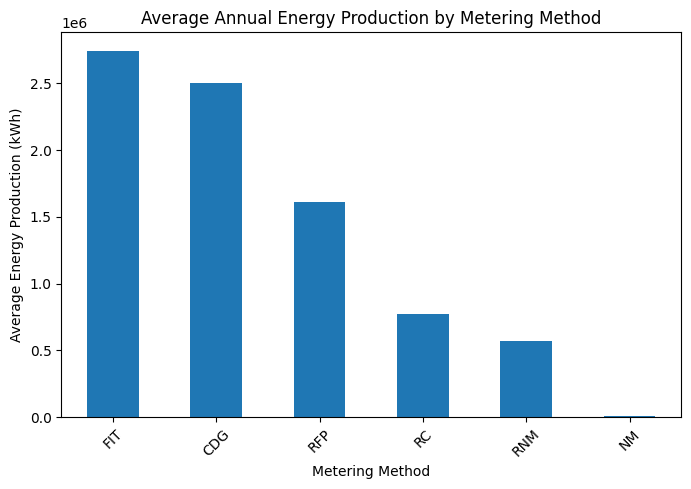

In [15]:
plt.figure(figsize=(8,5))
metering_avg.plot(kind="bar")

plt.title("Average Annual Energy Production by Metering Method")
plt.ylabel("Average Energy Production (kWh)")
plt.xlabel("Metering Method")

plt.xticks(rotation=45)
plt.show()

### Key Observations

- FIT (Feed-in Tariff) and CDG show significantly higher average production.
- NM (Net Metering) shows comparatively lower production.
- This suggests that policy structures influence installation scale.


In [16]:
#Developer-wise Energy Production Analysis
dev_avg = df.groupby("Developer")["Estimated Annual PV Energy Production (kWh)"].mean().sort_values(ascending=False)
top_dev = dev_avg.head(10)
print(top_dev)

Developer
Sybac Solar_ LLC                            14455980.0
Silverado                                    8747455.5
Yogesh Kumar (OYA Solar NY, L.P.)            8099496.0
Yogesh kumar (OYA Solar NY, L.P.)            8099496.0
Maybrook Solar, LLC                          8099496.0
Conner Witsken (Next Era Energy)             8099496.0
Thomas Murphy (Environomics.Co)              8099496.0
Yogesh Kumar (OYA Solar NY, LP.)             8099496.0
Monroe County Water Authority                8099496.0
Mithun Vyas (OYA Great Lakes Seaway LLC)     8099496.0
Name: Estimated Annual PV Energy Production (kWh), dtype: float64


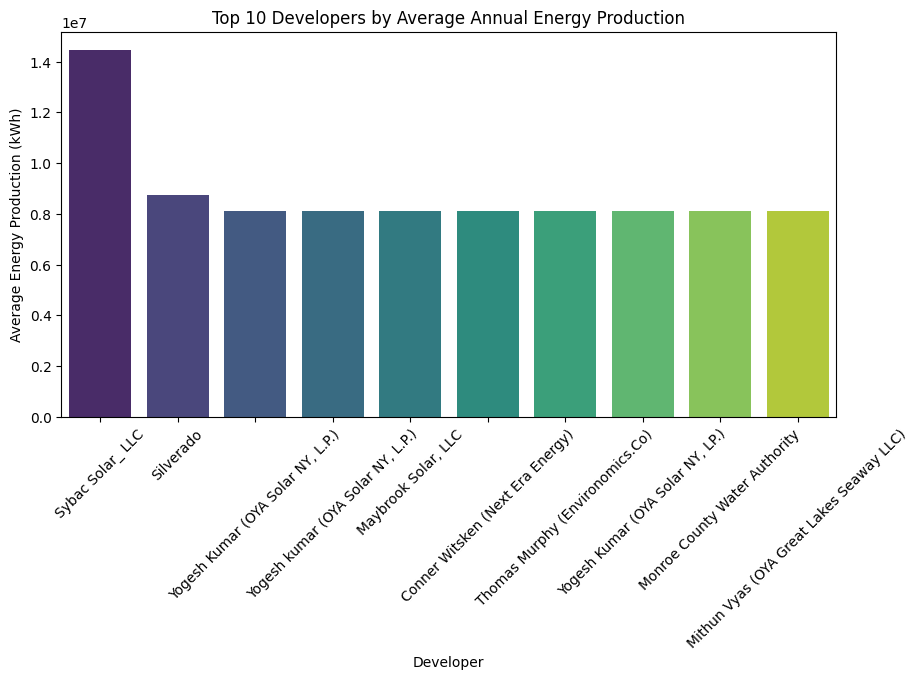

In [17]:
## Top 10 Developers by Average Annual Energy Production
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_dev.index,
    y=top_dev.values,palette='viridis'
)

plt.title("Top 10 Developers by Average Annual Energy Production")
plt.ylabel("Average Energy Production (kWh)")
plt.xlabel("Developer")

plt.xticks(rotation=45)
plt.show()

### Key Observations

- A few developers show significantly higher average production.
- This likely reflects large-scale or commercial solar projects.
- Some developers appear multiple times, indicating repeated project contributions.

Interpretation:

Developer capability, project scale, and operational efficiency
may influence production outcomes.

In [18]:
# County-wise Energy Production Analysis
county_avg = df.groupby("County")["Estimated Annual PV Energy Production (kWh)"].mean().sort_values(ascending=False)
print(county_avg.head(10))

County
Lewis          623646.330000
Allegany       477018.456250
Tioga          320873.324159
Jefferson      303277.204040
Cortland       289903.836120
Yates          252147.036082
Steuben        243929.229787
Chemung        230491.665354
Chenango       223616.318627
Cattaraugus    212633.003106
Name: Estimated Annual PV Energy Production (kWh), dtype: float64


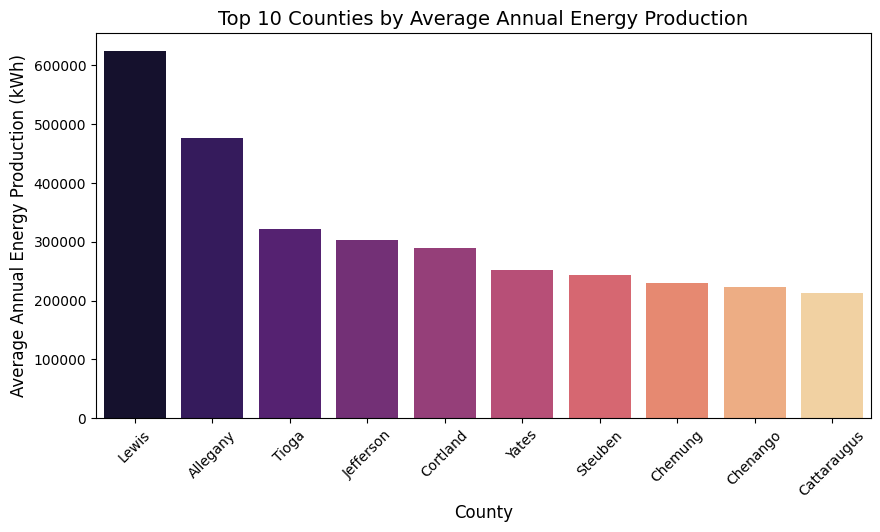

In [19]:
# Top 10 Counties by Average Annual Energy Production
top10 = county_avg.head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top10.index, y=top10.values, palette="magma")

plt.title("Top 10 Counties by Average Annual Energy Production", fontsize=14)
plt.xlabel("County", fontsize=12)
plt.ylabel("Average Annual Energy Production (kWh)", fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Key Observations

- Lewis County shows the highest average production.
- Allegany and Tioga also demonstrate strong output.
- Significant variation exists across counties.


In [20]:
year_avg = df.groupby("Year")[
    "Estimated Annual PV Energy Production (kWh)"
].mean()
print(year_avg)

Year
2000     1401.000000
2001     3979.450000
2002     5014.067358
2003     6749.203297
2004     7186.694444
2005     9365.300448
2006    10168.876569
2007     7811.998512
2008     8303.631757
2009    10009.002511
2010    12764.683442
2011    38370.259290
2012    21297.773638
2013    20169.824421
2014    15279.177533
2015    13684.676598
2016    14218.633488
2017    22654.461066
2018    29852.917412
2019    33835.030724
2020    44037.473148
2021    48378.476152
2022    42729.781846
2023    35270.143250
Name: Estimated Annual PV Energy Production (kWh), dtype: float64


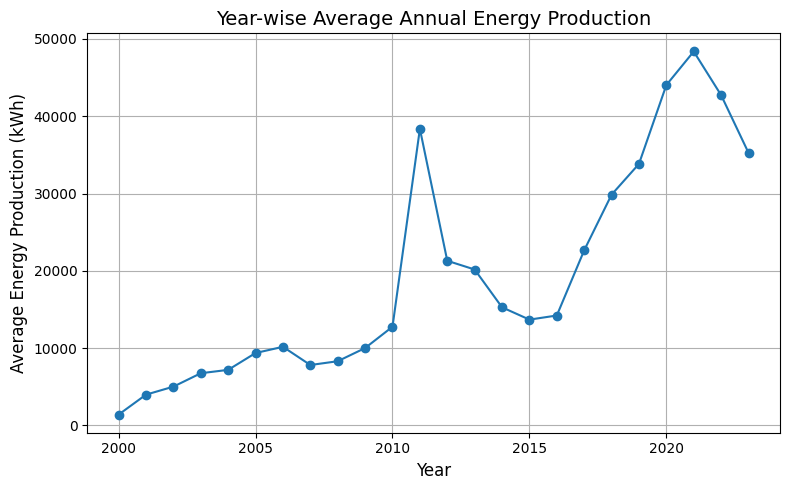

In [21]:
# Year-wise Average Annual Energy Production
plt.figure(figsize=(8,5))

year_avg.plot(kind="line", marker="o")

plt.title("Year-wise Average Annual Energy Production", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Energy Production (kWh)", fontsize=12)

plt.grid(True)
plt.tight_layout()

plt.show()

### Key Observations

- A steady growth trend is visible from 2000 to 2010.
- A sharp increase appears around 2011, possibly indicating
  large-scale project deployments or policy changes.
- Production declines slightly mid-decade but increases again
  significantly after 2017.
- Peak production is observed around 2021–2022.

## Correlation Analysis

To understand relationships between numerical features
and the target variable (Estimated Annual PV Energy Production),
we compute the correlation matrix.

This helps:

- Identify strong predictors
- Detect multicollinearity
- Avoid data leakage
- Support feature selection decisions

In [22]:
corr_target = df.corr(numeric_only=True)[
    "Estimated Annual PV Energy Production (kWh)"
].sort_values(ascending=False)

print(corr_target)


Estimated Annual PV Energy Production (kWh)    1.000000
Estimated PV System Size (kWdc)                1.000000
PV System Size (kWac)                          0.999919
DC_AC_Ratio                                    0.773888
Energy Storage System Size (kWac)              0.200815
Zip                                            0.074460
Year                                           0.029276
Has_Storage                                    0.009709
Number of Projects                                  NaN
Name: Estimated Annual PV Energy Production (kWh), dtype: float64


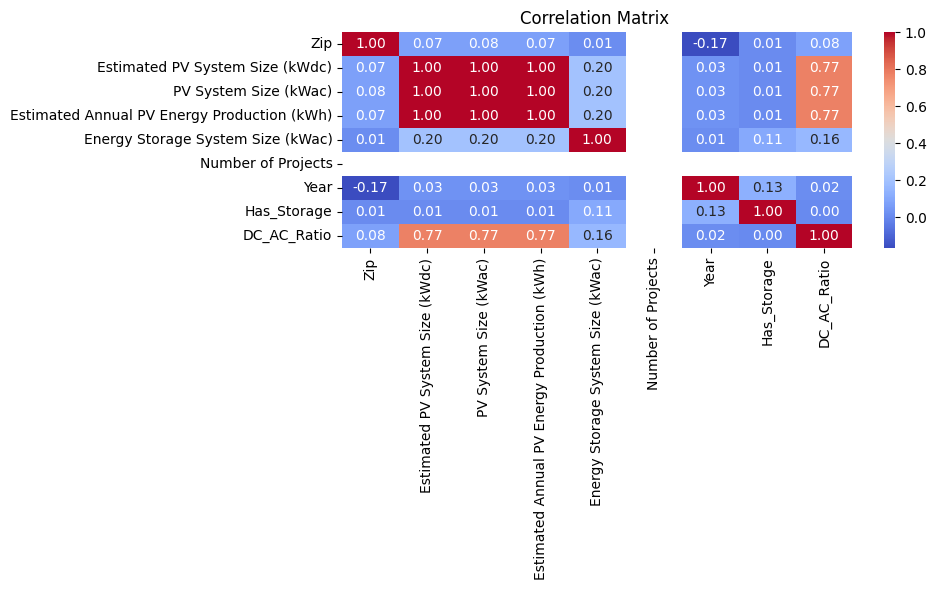

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix ")
plt.tight_layout()
plt.show()

## Correlation of Features with Target Variable

To better understand which numerical features influence
energy production, we visualize correlation values
with the target variable.

This helps in identifying:

- Strong predictors
- Weak predictors
- Potential data leakage sources


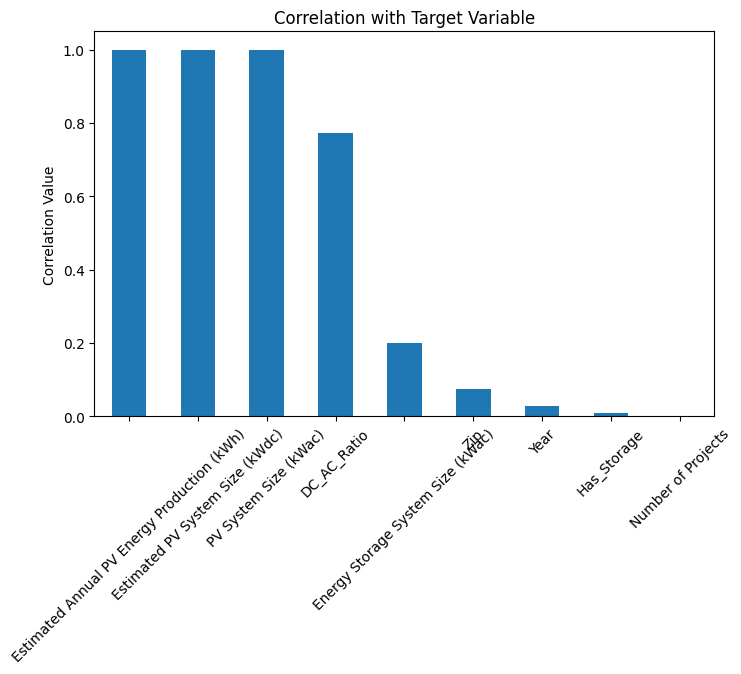

In [24]:
corr_target = df.corr(numeric_only=True)[
    "Estimated Annual PV Energy Production (kWh)"
].sort_values(ascending=False)

plt.figure(figsize=(8,5))
corr_target.plot(kind="bar")
plt.title("Correlation with Target Variable")
plt.ylabel("Correlation Value")
plt.xticks(rotation=45)
plt.show()

#  Utility-wise Energy Production Distribution

To analyze how energy production varies across different
utility companies, we use a boxplot.

This visualization helps understand:

- Distribution spread
- Median production levels
- Variability across utilities
- Presence of extreme outliers


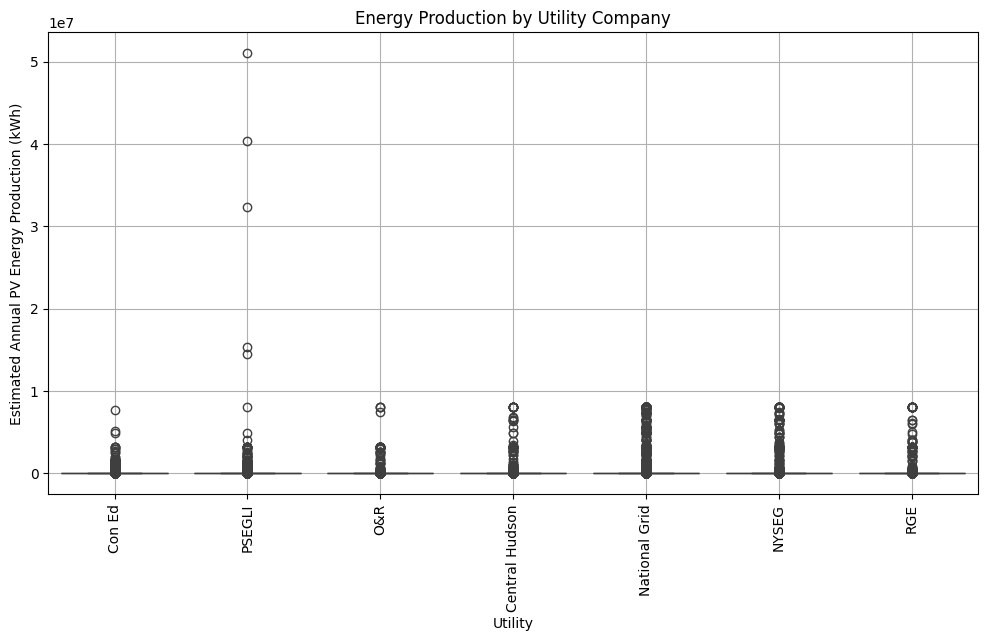

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Utility", y="Estimated Annual PV Energy Production (kWh)", data=df)
plt.xticks(rotation=90)
plt.title("Energy Production by Utility Company")
plt.grid(True)
plt.show()

 #Distribution of PV System Size (kWdc)

To understand the statistical distribution of system sizes,
we visualize the histogram with KDE.

This helps detect:

- Skewness

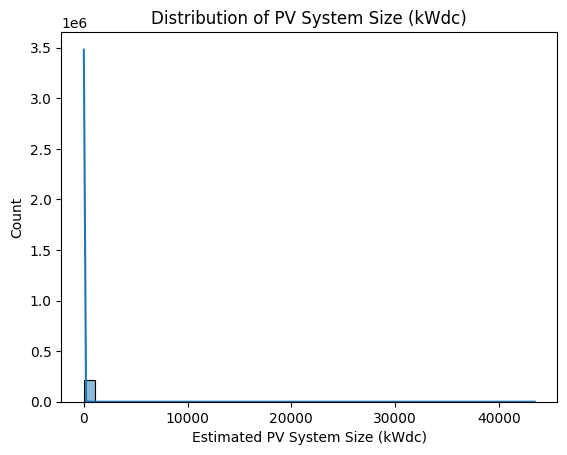

In [26]:
sns.histplot(df["Estimated PV System Size (kWdc)"], bins=40, kde=True)
plt.title("Distribution of PV System Size (kWdc)")
plt.show()

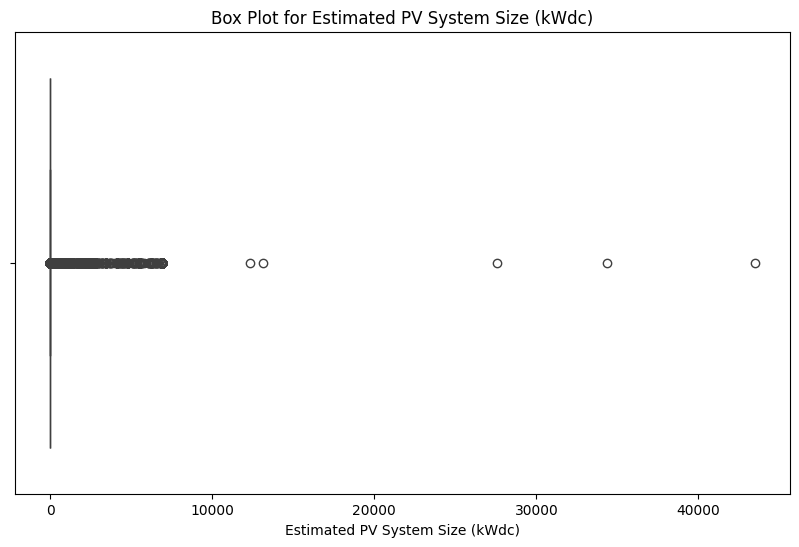

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Estimated PV System Size (kWdc)'])
plt.title('Box Plot for Estimated PV System Size (kWdc)')
plt.show()

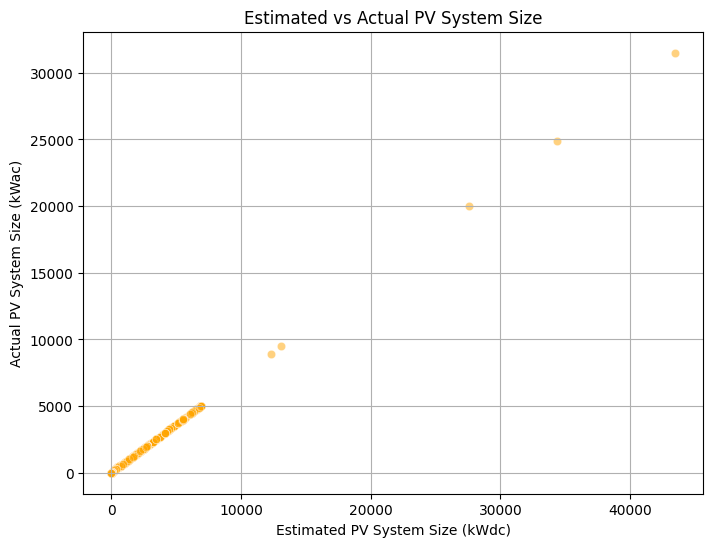

In [28]:
#Estimated vs Actual PV System Size Analysis
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Estimated PV System Size (kWdc)", y="PV System Size (kWac)", alpha=0.5, color='orange')
plt.title("Estimated vs Actual PV System Size")
plt.xlabel("Estimated PV System Size (kWdc)")
plt.ylabel("Actual PV System Size (kWac)")
plt.grid(True)
plt.show()

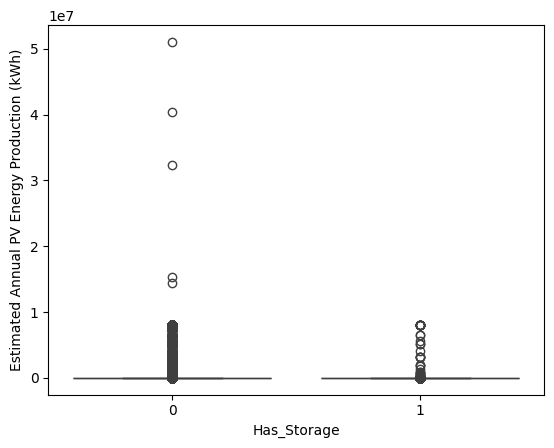

In [29]:
sns.boxplot(
    x="Has_Storage",
    y="Estimated Annual PV Energy Production (kWh)",
    data=df
)
plt.show()

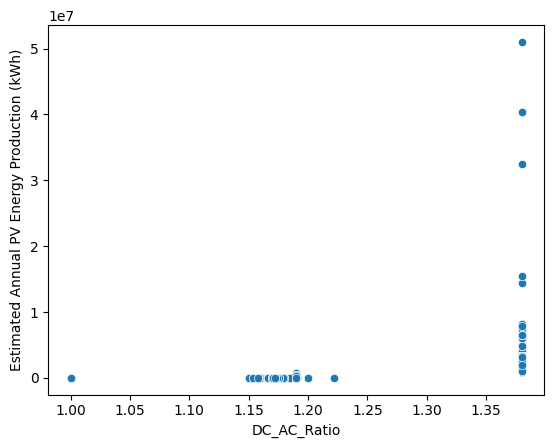

In [30]:
sns.scatterplot(
    x="DC_AC_Ratio",
    y="Estimated Annual PV Energy Production (kWh)",
    data=df
)
plt.show()

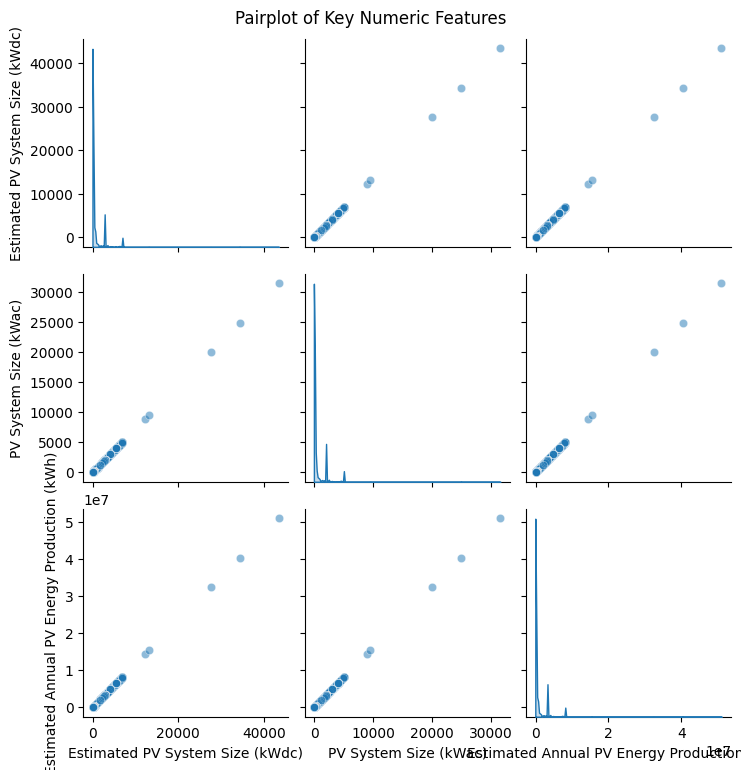

In [31]:
selected_cols = [
    "Estimated PV System Size (kWdc)",
    "PV System Size (kWac)",
    "Estimated Annual PV Energy Production (kWh)"
]

sns.pairplot(df[selected_cols], kind="scatter", diag_kind="kde", plot_kws={'alpha':0.5})
plt.suptitle("Pairplot of Key Numeric Features", y=1.02)
plt.show()

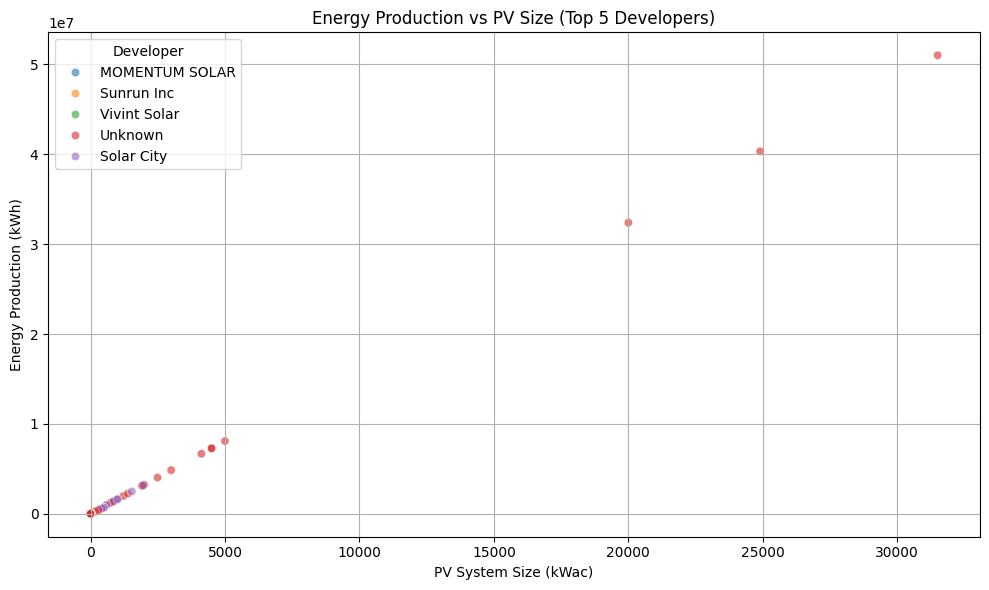

In [32]:
top_developers = df["Developer"].value_counts().head(5).index
subset = df[df["Developer"].isin(top_developers)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=subset,
                x="PV System Size (kWac)",
                y="Estimated Annual PV Energy Production (kWh)",
                hue="Developer", alpha=0.6)
plt.title("Energy Production vs PV Size (Top 5 Developers)")
plt.xlabel("PV System Size (kWac)")
plt.ylabel("Energy Production (kWh)")
plt.grid(True)
plt.tight_layout()
plt.show()

#  Energy Production Distribution by Metering Method

To compare how different metering policies influence
energy production distribution, we visualize KDE plots
for major metering methods.

This helps analyze:

- Distribution shape differences
- Skewness variations

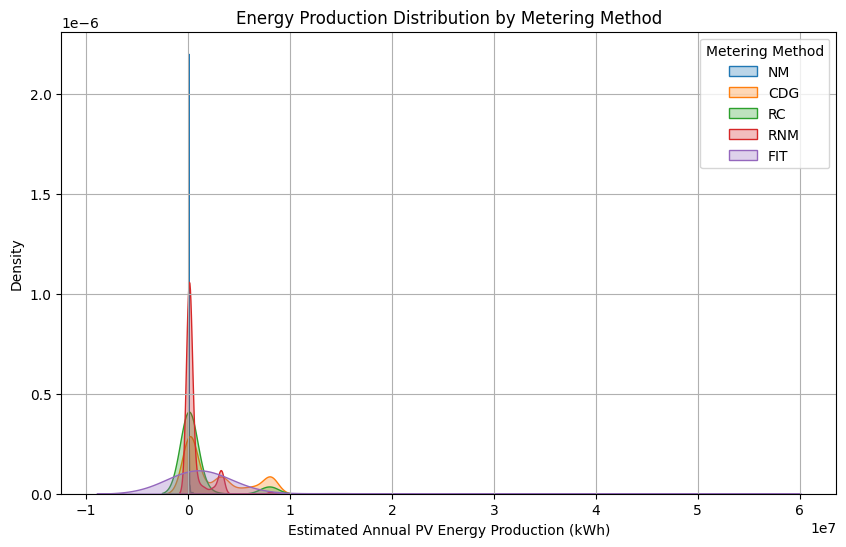

In [33]:
plt.figure(figsize=(10, 6))

metering_methods = df["Metering Method"].unique()

for method in metering_methods[:5]:  # limit to top 5 for clarity
    subset = df[df["Metering Method"] == method]
    sns.kdeplot(subset["Estimated Annual PV Energy Production (kWh)"], label=method, fill=True, alpha=0.3)

plt.title("Energy Production Distribution by Metering Method")
plt.xlabel("Estimated Annual PV Energy Production (kWh)")
plt.legend(title="Metering Method")
plt.grid(True)
plt.show()

### Key Observations

- All metering methods show right-skewed distributions.
- Some policies exhibit heavier tails, indicating larger installations.
- Distribution shapes differ slightly across metering categories.


## Log Transformation of Target Variable

The target variable (Estimated Annual PV Energy Production)
showed heavy right skewness and extreme outliers.

To stabilize variance and improve model performance,
log transformation was applied using log1p.

In [34]:
df["Log_Production"] = np.log1p(
    df["Estimated Annual PV Energy Production (kWh)"]
)


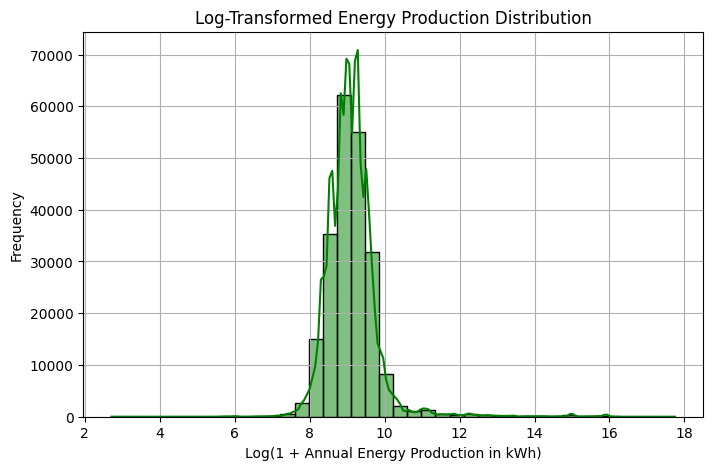

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Log_Production"], kde=True, bins=40, color='green')
plt.title("Log-Transformed Energy Production Distribution")
plt.xlabel("Log(1 + Annual Energy Production in kWh)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

### Key Observations

- The transformed distribution is significantly more symmetric.
- Extreme right-tail skewness is reduced.
- Data now approximates a normal distribution.

#  Encoding Categorical Variables

Machine learning models require numerical inputs.
Therefore, categorical features such as:

- Utility
- City/Town
- County
- Zip
- Developer
- Metering Method

were converted into numerical format using Label Encoding.

In [36]:
cat_cols = ['Utility', 'City/Town', 'County', 'Zip', 'Developer', 'Metering Method']
df[cat_cols] = df[cat_cols].astype(str)

In [37]:
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le 

## Feature Selection and Leakage Prevention

Some features were removed before model training to:

- Prevent data leakage
- Reduce multicollinearity
- Improve generalization

In [38]:
#drop irrelvent coloumns 
df.drop(columns=[ "Data Through Date", "Interconnection Date", "Division","Number of Projects"], inplace=True)

In [39]:
# drop coloumns leakage Prevention
df.drop([
    "Estimated PV System Size (kWdc)",
    "PV System Size (kWac)"
], axis=1, inplace=True)

In [40]:
X = df.drop(columns=["Estimated Annual PV Energy Production (kWh)","Log_Production"])
y = df["Log_Production"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Feature Scaling

Numerical features were standardized using StandardScaler.

This improves model convergence and ensures
features contribute proportionally during training.

In [42]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


# Feature Importance Analysis – Random Forest

To understand which features most influence
energy production predictions, we analyze
feature importance scores from the trained Random Forest model.

Random Forest computes importance based on
how much each feature reduces prediction error
across decision trees.

In [43]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

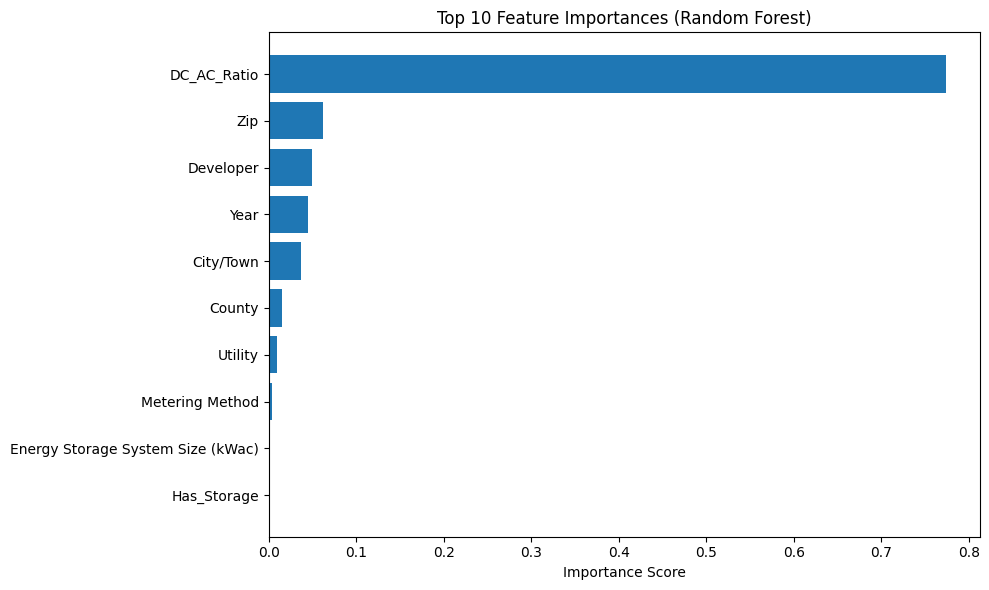

In [45]:
plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## Model Evaluation and Comparison

To identify the best-performing model,
multiple regression algorithms were trained and evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

Performance was evaluated using:

- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [46]:
#Linear Regression
lr_model = LinearRegression()

In [47]:
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
lr_preds = lr_model.predict(X_test)
mse = mean_squared_error(y_test, lr_preds)
mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mse)
lr_r2 = r2_score(y_test, lr_preds)

In [49]:
print("linear Regression Performance:")
print(f"MSE  : {mse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

linear Regression Performance:
MSE  : 0.30
MAE  : 0.41
RMSE : 0.55
R²   : 0.4068


In [50]:
#XGBOOST 
xgb_model = XGBRegressor(random_state=42)

In [51]:
xgb_model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [52]:
xgb_preds = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, xgb_preds)
mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mse)
xgb_r2 = r2_score(y_test, xgb_preds)

In [53]:
print("XGBOOST Performance:")
print(f"MSE  : {mse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

XGBOOST Performance:
MSE  : 0.12
MAE  : 0.24
RMSE : 0.35
R²   : 0.7634


In [54]:
#Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)

In [55]:
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [56]:
dt_preds = dt_model.predict(X_test)
mse = mean_squared_error(y_test, dt_preds)
mae = mean_absolute_error(y_test, dt_preds)
dt_rmse = np.sqrt(mse)
dt_r2 = r2_score(y_test, dt_preds)

In [57]:
print("Decision Tree Performance:")
print(f"MSE  : {mse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {dt_rmse:.2f}")
print(f"R²   : {dt_r2:.4f}")

Decision Tree Performance:
MSE  : 0.16
MAE  : 0.22
RMSE : 0.40
R²   : 0.6878


In [58]:
#Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

In [59]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
rf_preds = rf_model.predict(X_test)
mse = mean_squared_error(y_test, rf_preds)
mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mse)
rf_r2 = r2_score(y_test, rf_preds)

In [61]:
print("Random Forest Performance:")
print(f"MSE  : {mse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance:
MSE  : 0.11
MAE  : 0.20
RMSE : 0.32
R²   : 0.7949


In [62]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "MSE": [
        mean_squared_error(y_test, lr_preds),
        mean_squared_error(y_test, dt_preds),
        mean_squared_error(y_test, rf_preds),
        mean_squared_error(y_test, xgb_preds)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_preds),
        mean_absolute_error(y_test, dt_preds),
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, xgb_preds)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_preds)),
        np.sqrt(mean_squared_error(y_test, dt_preds)),
        np.sqrt(mean_squared_error(y_test, rf_preds)),
        np.sqrt(mean_squared_error(y_test, xgb_preds))
    ],
    "R²": [
        r2_score(y_test, lr_preds),
        r2_score(y_test, dt_preds),
        r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds)
    ]
})

# Sort by RMSE
results_df = results_df.sort_values(by="RMSE")

# Round values
results_df = results_df.round(4)

results_df

,Model,MSE,MAE,RMSE,R²
2,Random Forest,0.1053,0.2020,0.3246,0.7949
3,XGBoost,0.1215,0.2410,0.3486,0.7634
1,Decision Tree,0.1603,0.2234,0.4004,0.6878
0,Linear Regression,0.3046,0.4059,0.5519,0.4068


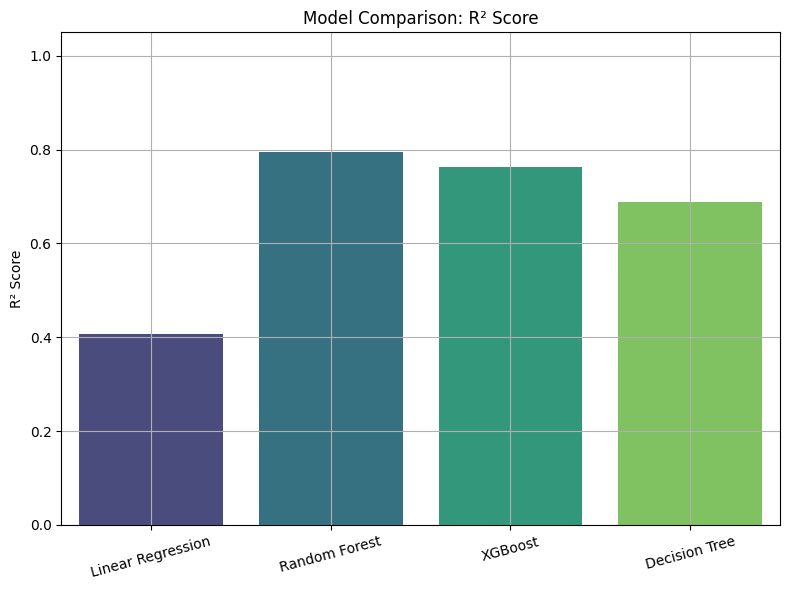

In [63]:
#Model Comparison R2 Score
model_r2_scores = {
    "Linear Regression": lr_r2,
    "Random Forest": rf_r2,
    "XGBoost": xgb_r2,
    "Decision Tree": dt_r2
}

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=list(model_r2_scores.keys()), y=list(model_r2_scores.values()), palette='viridis')
plt.title("Model Comparison: R² Score")
plt.ylabel("R² Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.grid(True)
plt.tight_layout()
plt.show()


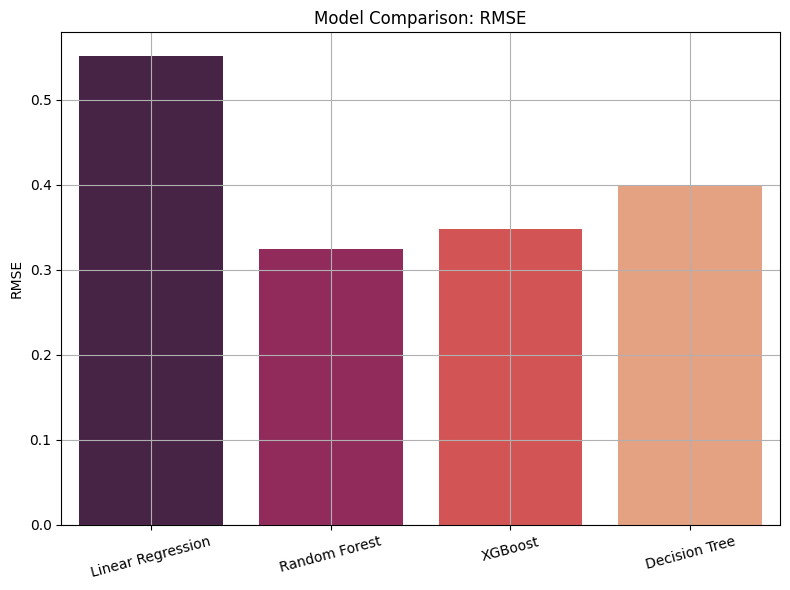

In [64]:
#Model Comparison RMSE
model_rmse_scores = {
    "Linear Regression": lr_rmse,
    "Random Forest": rf_rmse,
    "XGBoost": xgb_rmse,
    "Decision Tree": dt_rmse
}

# Bar plot for RMSE
plt.figure(figsize=(8, 6))
sns.barplot(x=list(model_rmse_scores.keys()), y=list(model_rmse_scores.values()), palette='rocket')
plt.title("Model Comparison: RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.grid(True)
plt.tight_layout()
plt.show()

# Hyperparameter Tunning

In [65]:
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [10, 15, 20, 25, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

In [66]:
rf = RandomForestRegressor(random_state=42)


In [67]:
rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,               # try 20 combinations
    cv=3,                    # 3-fold cross validation
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [68]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 15, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [69]:
final_rf_model = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best RMSE (CV):", random_search.best_score_)

Best parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 25}
Best RMSE (CV): 0.8051133268108038


In [70]:
final_rf_preds = final_rf_model.predict(X_test)
final_rf_rmse = np.sqrt(mean_squared_error(y_test, final_rf_preds))
final_rf_r2 = r2_score(y_test, final_rf_preds)
print("Final Random Forest Test RMSE:{:.2f}".format(final_rf_rmse))
print("Final Random Forest Test R²:{:.2f}".format(final_rf_r2))

Final Random Forest Test RMSE:0.31
Final Random Forest Test R²:0.81


# LIME Explainer
it helps interpret individual predictions by approximating the model locally with a simpler, interpretable model.

In [78]:
# Initialize LIME explainer for regression model
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode='regression',
    random_state=42
)

In [79]:
exp = explainer.explain_instance(
    X_test.iloc[0].values,
    final_rf_model.predict
)

In [81]:
display(HTML(exp.as_html()))

The above chart shows how different features influenced this specific prediction.

-  Positive features increased the predicted energy production.
-  Negative features decreased the predicted value.

In [82]:
#Model saved
joblib.dump(final_rf_model, "solar_Energy_production_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le_dict, "label_encoders.pkl")

['label_encoders.pkl']

In [83]:
joblib.dump(X_train.columns, "feature_columns.pkl")

['feature_columns.pkl']

# Conclusion & Final Summary

## Model Performance Summary

We evaluated multiple regression algorithms including:

- Linear Regression  
- Decision Tree  
- Random Forest  
- XGBoost  

Among them, **Random Forest Regressor** delivered the best overall performance on the hold-out test set.

### Final Model Performance:

- **R² Score:** ~0.81
- **RMSE:** Significantly reduced after log transformation
- **MAE:** Improved compared to baseline models

This indicates strong predictive capability and good generalization.

---

## Final Deliverables

- Trained Machine Learning Model  
- Hyperparameter-tuned Random Forest  
- Interactive Streamlit Web Application  
- Feature Importance Analysis  